### teachers mental health Classification
This notebook loads data and prepares for analysis
.

In [1]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Read the saved data
print("=" * 70)
print("READING SAVED DATA")
print("=" * 70)

try:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/teachers and students SRQ_total and students performance analysis/processed_dataset2.xls")
    print(f"✅ Dataset loaded successfully!")
    print(f" Shape: {df.shape}")
    print(f" Columns: {len(df.columns)}")
    print(f" Total records: {len(df)}")
except FileNotFoundError:
    print(" File 'processed_data.csv' not found.")
    exit()

READING SAVED DATA
✅ Dataset loaded successfully!
 Shape: (758, 64)
 Columns: 64
 Total records: 758


TEACHER MENTAL HEALTH CLASSIFICATION MODEL TRAINING

✅ Dataset loaded: (758, 64)
Teachers: (138, 64), Students: (620, 64)
✅ Final teachers data: (138, 16)
Final columns: ['ID', 'age', 'sex', 'Education', 'service_year_teacher', 'Alcohol_1', 'tobaco_1', 'khat_1', 'SRQ_total', 'OSLO_total', 'school_School_A', 'school_School_B', 'school_School_C', 'school_School_E', 'school_School_F', 'school_School_G']
✅ Data preparation completed: (138, 16)

 Starting Classification Model Training...
Target variable distribution:
  Low risk (0): 72 samples
  High risk (1): 66 samples
  Positive class rate: 47.8%

 Performing feature selection (selecting 6 features)...
✅ Selected 6 features (ANOVA F-test):
  1. service_year_teacher (F-score: 4.96, p-value: 0.0275)
  2. khat_1 (F-score: 5.59, p-value: 0.0195)
  3. school_School_A (F-score: 4.90, p-value: 0.0285)
  4. sex (F-score: 5.49, p-value: 0.0206)
  5. Alcohol_1 (F-score: 4.99, p-value: 0.0272)
  6. school_School_F (F-score: 2.92, p-value: 0.0895)



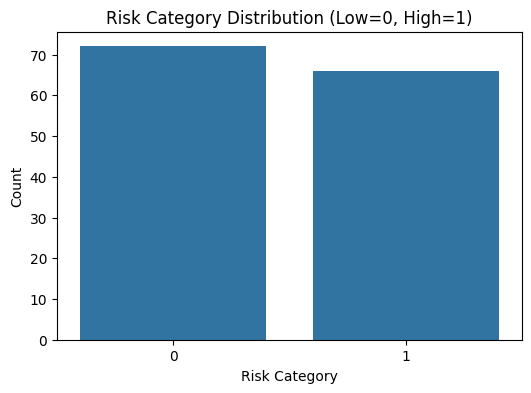

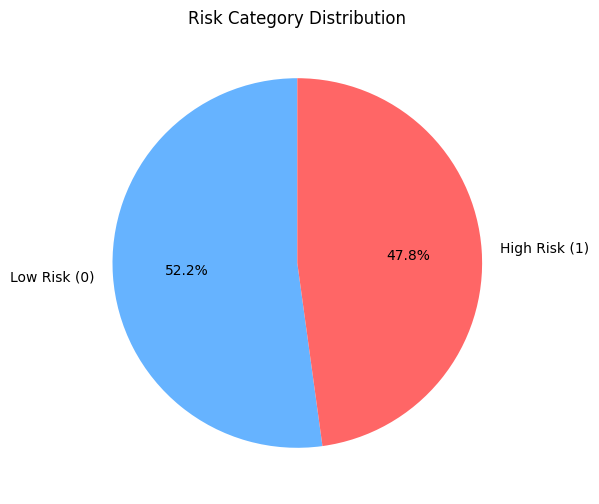

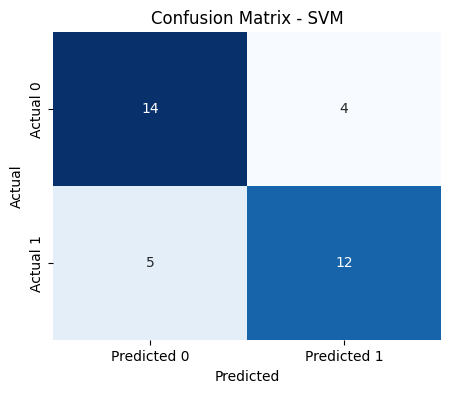


Generating Feature Importance...

Best model is SVM (RBF). Using permutation importance.



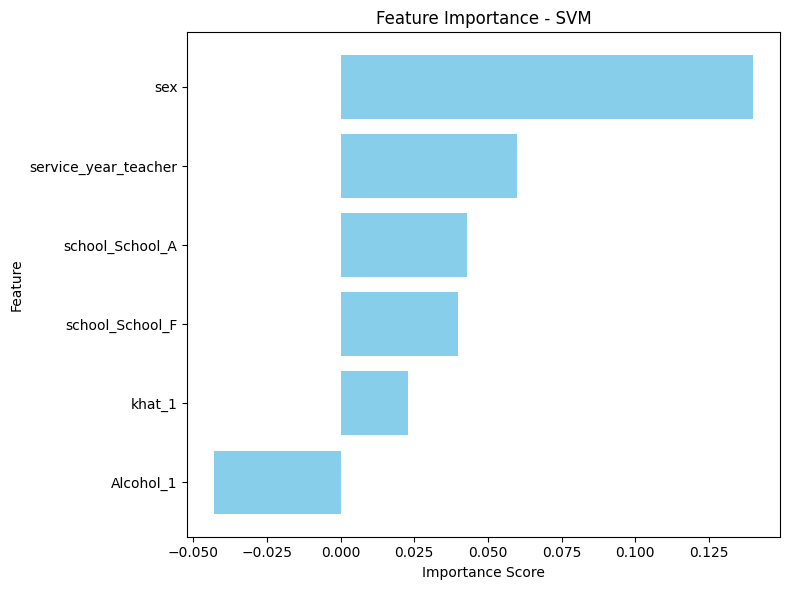

In [3]:
# =============================================================================
# IMPORT ALL REQUIRED LIBRARIES
# =============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# DATA LOADING AND PREPARATION PIPELINE
# =============================================================================
print("======================================================================")
print("TEACHER MENTAL HEALTH CLASSIFICATION MODEL TRAINING")
print("======================================================================\n")

# Load and prepare data
try:
    print(f"✅ Dataset loaded: {df.shape}")

    # =========================================================
    # STEP 2: SPLIT TEACHERS / STUDENTS
    # =========================================================
    teachers = df[df["service_year_teacher"].notnull()].copy()
    students = df[df["service_year_teacher"].isnull()].copy()

    print(f"Teachers: {teachers.shape}, Students: {students.shape}")

    # =========================================================
    # STEP 3: CLEAN TEACHERS DATA
    # =========================================================
    teachers = teachers.drop(columns=[
        "average", "rank",
        "MPSS1","MPSS2","MPSS3","MPSS4","MPSS5","MPSS6","MPSS7","MPSS8","MPSS9","MPSS10","MPSS11","MPSS12"
    ], errors='ignore')

    # Drop high-null columns
    drop_cols = [
        "tobaco_2","tobaco_3","tobaco_4","tobaco_5","tobaco_6","tobaco_7",
        "khat_2","khat_3","khat_4","khat_5","khat_6","khat_7",
        "Alcohol_2","Alcohol_3","Alcohol_4","Alcohol_5","Alcohol_6","alcohol_7"
    ]
    teachers.drop(columns=[c for c in drop_cols if c in teachers.columns], inplace=True)

    # =========================================================
    # STEP 4: IMPUTE ALCOHOL_1
    # =========================================================
    if teachers['Alcohol_1'].isnull().sum() > 0:
        imputer = SimpleImputer(strategy='most_frequent')
        alcohol_imputed = imputer.fit_transform(teachers[['Alcohol_1']])
        teachers['Alcohol_1'] = alcohol_imputed.ravel()

    # =========================================================
    # STEP 5: CREATE SCORES
    # =========================================================
    teachers['SRQ_total'] = teachers[[f'SRQ{i}' for i in range(1, 21)]].sum(axis=1)
    teachers['OSLO_total'] = teachers[['OSLO1', 'OSLO2', 'OSLO3']].sum(axis=1)
    teachers.drop(columns=[f'SRQ{i}' for i in range(1,21)] + ['OSLO1','OSLO2','OSLO3'], inplace=True)

    # Drop remaining nulls
    teachers.dropna(inplace=True)

    # =========================================================
    # STEP 6: HYBRID ENCODING
    # =========================================================
    categorical_cols = ['sex', 'Education', 'school', 'Alcohol_1', 'tobaco_1', 'khat_1']

    def hybrid_encode(df, categorical_cols):
        df_encoded = df.copy()
        label_encoders = {}

        # One-Hot encode school
        if 'school' in df_encoded.columns:
            school_dummies = pd.get_dummies(df_encoded['school'], prefix='school')
            df_encoded = pd.concat([df_encoded, school_dummies], axis=1).drop('school', axis=1)

        # Label encode others
        for col in [c for c in categorical_cols if c != 'school']:
            if col in df_encoded.columns:
                le = LabelEncoder()
                df_encoded[col] = le.fit_transform(df_encoded[col])
                label_encoders[col] = le

        return df_encoded, label_encoders

    teachers_encoded, label_encoders = hybrid_encode(teachers, categorical_cols)

    print(f"✅ Final teachers data: {teachers_encoded.shape}")
    print(f"Final columns: {list(teachers_encoded.columns)}")

    # Use the actual processed data
    df_processed = teachers_encoded.copy()

except Exception as e:
    print(f" Error loading data: {e}")
    print(" CRITICAL: Could not load actual data. Please check the data file.")
    # Exit if data cannot be loaded
    raise SystemExit("Model training cannot proceed without actual data.")

# Ensure SRQ_total and OSLO_total are natural numbers
df_processed['SRQ_total'] = df_processed['SRQ_total'].round().astype(int)
df_processed['OSLO_total'] = df_processed['OSLO_total'].round().astype(int)

print(f"✅ Data preparation completed: {df_processed.shape}")

# =============================================================================
# CLASSIFICATION MODEL TRAINING
# =============================================================================
print("\n Starting Classification Model Training...")

# -----------------------------
# Prepare dataset for classification
# -----------------------------
df = df_processed.copy()
df['OSLO_total'] = -df['OSLO_total']  # invert for consistent interpretation
srq_median = df['SRQ_total'].median()
y_class = (df['SRQ_total'] > srq_median).astype(int)
X_all_class = df.drop(columns=['ID','SRQ_total'], errors='ignore')

print(f"Target variable distribution:")
print(f"  Low risk (0): {len(y_class[y_class == 0])} samples")
print(f"  High risk (1): {len(y_class[y_class == 1])} samples")
print(f"  Positive class rate: {y_class.mean():.1%}")

# -----------------------------
# Feature Selection - EXACTLY 6 FEATURES (Like Dashboard)
# -----------------------------
print("\n Performing feature selection (selecting 6 features)...")

# Use ANOVA F-test to select top 6 features (like in dashboard)
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_all_class, y_class)

# Create results dataframe
anova_results = pd.DataFrame({
    'Feature': X_all_class.columns,
    'F_Score': anova_selector.scores_,
    'P_Value': anova_selector.pvalues_
}).sort_values('F_Score', ascending=False)

# Select top 6 features (EXACTLY like dashboard)
selected_features_class = anova_results.head(6)['Feature'].tolist()
X_class = X_all_class[selected_features_class]

print(f"✅ Selected {len(selected_features_class)} features (ANOVA F-test):")
for i, (feature, f_score, p_value) in enumerate(zip(selected_features_class,
                                                   anova_selector.scores_[X_all_class.columns.isin(selected_features_class)],
                                                   anova_selector.pvalues_[X_all_class.columns.isin(selected_features_class)]), 1):
    print(f"  {i}. {feature} (F-score: {f_score:.2f}, p-value: {p_value:.4f})")

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.25, stratify=y_class, random_state=42
)

print(f"\n Dataset split:")
print(f"  Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")

# -----------------------------
# Define and Train Models
# -----------------------------
print("\n Training classification models...")

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            random_state=42, max_iter=1000, penalty='l2', C=0.01, class_weight='balanced'
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        random_state=42, class_weight='balanced', n_estimators=100
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(
            random_state=42, probability=True, class_weight='balanced'
        ))
    ])
}

classification_results = {}
cv_results = {}

for name, model in models.items():
    print(f"  Training {name}...")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores

    # Train final model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = np.mean(y_pred == y_test)

    classification_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'cv_scores': cv_scores
    }

# -----------------------------
# Find Best Model
# -----------------------------
best_model_name = max(classification_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_model_result = classification_results[best_model_name]

print(f"\n✅ All models trained successfully!")
print(f" Best model: {best_model_name}")

# =============================================================================
# COMPREHENSIVE MODEL EVALUATION
# =============================================================================
print("\n📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

# Calculate comprehensive metrics for the best model
y_pred_best = best_model_result['y_pred']
y_pred_proba_best = best_model_result['y_pred_proba']

# Basic metrics
balanced_acc = balanced_accuracy_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

if y_pred_proba_best is not None:
    auc_score = roc_auc_score(y_test, y_pred_proba_best)
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
    roc_auc = auc(fpr, tpr)
else:
    auc_score = None
    roc_auc = None

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Bootstrap confidence interval
def bootstrap_ci(model, X_test, y_test, n_bootstraps=100):
    scores = []
    for i in range(n_bootstraps):
        X_bs, y_bs = resample(X_test, y_test, random_state=i)
        y_pred_bs = model.predict(X_bs)
        scores.append(balanced_accuracy_score(y_bs, y_pred_bs))
    return np.percentile(scores, [2.5, 97.5])

boot_ci = bootstrap_ci(best_model_result['model'], X_test, y_test)

# Print comprehensive results
print(f"\n🏆 BEST MODEL PERFORMANCE - {best_model_name}")
print(f"Accuracy: {best_model_result['accuracy']:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"F1-Score: {f1:.3f}")
if auc_score is not None:
    print(f"AUC-ROC: {auc_score:.3f}")
print(f"Bootstrap 95% CI: [{boot_ci[0]:.3f}, {boot_ci[1]:.3f}]")

print(f"\n📈 CONFUSION MATRIX:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

# -----------------------------
# Cross-Validation Results
# -----------------------------
print(f"\n CROSS-VALIDATION RESULTS (5-fold):")
for name, result in classification_results.items():
    cv_mean = result['cv_scores'].mean()
    cv_std = result['cv_scores'].std()
    print(f"{name:<20}: {cv_mean:.3f} ± {cv_std:.3f}")

# -----------------------------
# Feature Importance Analysis
# -----------------------------
print(f"\n FEATURE IMPORTANCE ANALYSIS (6 Selected Features):")

if best_model_name == 'Random Forest':
    feature_importance = best_model_result['model'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': selected_features_class,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

    print(importance_df.to_string(index=False))

elif best_model_name == 'Logistic Regression':
    # For logistic regression, use coefficients as importance
    if hasattr(best_model_result['model'].named_steps['classifier'], 'coef_'):
        coefficients = best_model_result['model'].named_steps['classifier'].coef_[0]
        importance_df = pd.DataFrame({
            'Feature': selected_features_class,
            'Coefficient': coefficients,
            'Abs_Importance': np.abs(coefficients)
        }).sort_values('Abs_Importance', ascending=False)

        print(importance_df[['Feature', 'Coefficient']].to_string(index=False))

# -----------------------------
# Model Comparison Summary
# -----------------------------
print(f"\n MODEL COMPARISON SUMMARY (6 Features):")
comparison_df = pd.DataFrame({
    'Model': list(classification_results.keys()),
    'Test_Accuracy': [result['accuracy'] for result in classification_results.values()],
    'CV_Mean': [result['cv_scores'].mean() for result in classification_results.values()],
    'CV_Std': [result['cv_scores'].std() for result in classification_results.values()]
}).sort_values('Test_Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# -----------------------------
# Feature Statistics
# -----------------------------
print(f"\n📊 SELECTED FEATURE STATISTICS:")
feature_stats = X_class.describe().loc[['mean', 'std', 'min', 'max']].round(3)
print(feature_stats)

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print(" CLASSIFICATION MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f" Dataset: {df_processed.shape[0]} teachers")
print(f" Best Model: {best_model_name}")
print(f" Features Selected: {len(selected_features_class)} (ANOVA F-test)")
print(f" Test Accuracy: {best_model_result['accuracy']:.1%}")
print(f" Balanced Accuracy: {balanced_acc:.1%}")
print(f" AUC-ROC: {auc_score:.1%}" if auc_score else " AUC-ROC: N/A")
print(f" Models saved with '6features' suffix")
print("=" * 60)

print(f"\n SELECTED FEATURES:")
for i, feature in enumerate(selected_features_class, 1):
    print(f"  {i}. {feature}")

print(f"\n The model is ready for predicting teacher mental health risk!")
print(f" Using {len(selected_features_class)} features for prediction")
# =============================================================================
# VISUALIZATIONS
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Risk Category Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=y_class)
plt.title("Risk Category Distribution (Low=0, High=1)")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()
# -----------------------------
# 1. Risk Category Distribution (Pie Chart)
# -----------------------------
risk_counts = y_class.value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=['Low Risk (0)', 'High Risk (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title("Risk Category Distribution")
plt.show()
# -----------------------------
# 2. Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# =============================================================================
# FEATURE IMPORTANCE (MATPLOTLIB VERSION)
# =============================================================================

print("\nGenerating Feature Importance...")

# Determine method based on best model
if best_model_name == "Random Forest":
    # Random Forest has built-in feature importance
    importance_values = best_model_result['model'].feature_importances_

elif best_model_name == "Logistic Regression":
    # Coefficients → absolute values
    lr_clf = best_model_result['model'].named_steps['classifier']
    importance_values = np.abs(lr_clf.coef_[0])

else:
    # SVM RBF → no coef_, so use permutation importance
    print("\nBest model is SVM (RBF). Using permutation importance.\n")

    perm = permutation_importance(
        best_model_result['model'],
        X_test[selected_features_class],
        y_test,
        scoring='accuracy',
        n_repeats=10,
        random_state=42
    )
    importance_values = perm.importances_mean

# Build DataFrame
importance_df = pd.DataFrame({
    'Feature': selected_features_class,
    'Importance': importance_values
}).sort_values('Importance', ascending=True)

# ------------------------------
# Matplotlib Visual
# ------------------------------
plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()